# 02 — Baseline Custom CNN

Train a 4-block CNN from scratch as our baseline model.

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

# CUDA setup — must be before TF import
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/home/yuujin/school/cv-final-project/.cuda"

import tensorflow as tf
print(f"TensorFlow {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

# Enable GPU memory growth to avoid allocating all VRAM at once
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

2026-02-12 16:04:03.709452: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-12 16:04:03.762432: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-02-12 16:04:04.767512: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from src.data_loader import load_and_split_data, create_dataset, get_class_weights
from src.models import build_custom_cnn
from src.train import get_callbacks, train_model
from src.evaluate import evaluate_model, plot_confusion_matrix, plot_training_curves

DATA_DIR = os.path.join("..", "data", "raw", "standardized_256")

## 1. Load and Split Data

In [3]:
train_paths, train_labels, val_paths, val_labels, test_paths, test_labels, class_names = \
    load_and_split_data(DATA_DIR)

print(f"Classes: {class_names}")
print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Train: 9343 | Val: 2002 | Test: 2003


In [4]:
train_ds = create_dataset(train_paths, train_labels, augment=True)
val_ds = create_dataset(val_paths, val_labels, augment=False, shuffle=False)
test_ds = create_dataset(test_paths, test_labels, augment=False, shuffle=False)

class_weights = get_class_weights(train_labels)
print(f"Class weights: {class_weights}")

Class weights: {0: 1.6391228070175439, 1: 1.6477954144620812, 2: 0.8707362534948742, 3: 0.67264218862491, 4: 0.6683118741058656, 5: 1.34431654676259, 6: 0.9671842650103519, 7: 0.7811872909698997, 8: 0.8174103237095363, 9: 2.7002890173410403}


I0000 00:00:1770887048.246482   43983 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4140 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


## 2. Build Model

In [5]:
num_classes = len(class_names)
model = build_custom_cnn(num_classes)
model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,698 (1.75 MB)

 Trainable params: 457,738 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

## 3. Train

In [6]:
callbacks = get_callbacks("custom_cnn")
history = train_model(
    model, train_ds, val_ds,
    epochs=50,
    class_weights=class_weights,
    callbacks=callbacks,
    lr=1e-3,
)

Epoch 1/50


2026-02-12 16:04:12.212503: I external/local_xla/xla/service/service.cc:163] XLA service 0x78d940005170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-12 16:04:12.212612: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9


2026-02-12 16:04:12.451820: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


2026-02-12 16:04:12.974154: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-02-12 16:04:13.099713: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


2026-02-12 16:04:13.681007: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1829', 16 bytes spill stores, 16 bytes spill loads



...

291/292 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.0554 - loss: 2.3176

292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.0554 - loss: 2.3176


Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 12: val_loss did not improve from 2.29863


292/292 ━━━━━━━━━━━━━━━━━━━━ 49s 165ms/step - accuracy: 0.0558 - loss: 2.3027 - val_accuracy: 0.0370 - val_loss: 2.3026 - learning_rate: 5.0000e-04


## 4. Training Curves

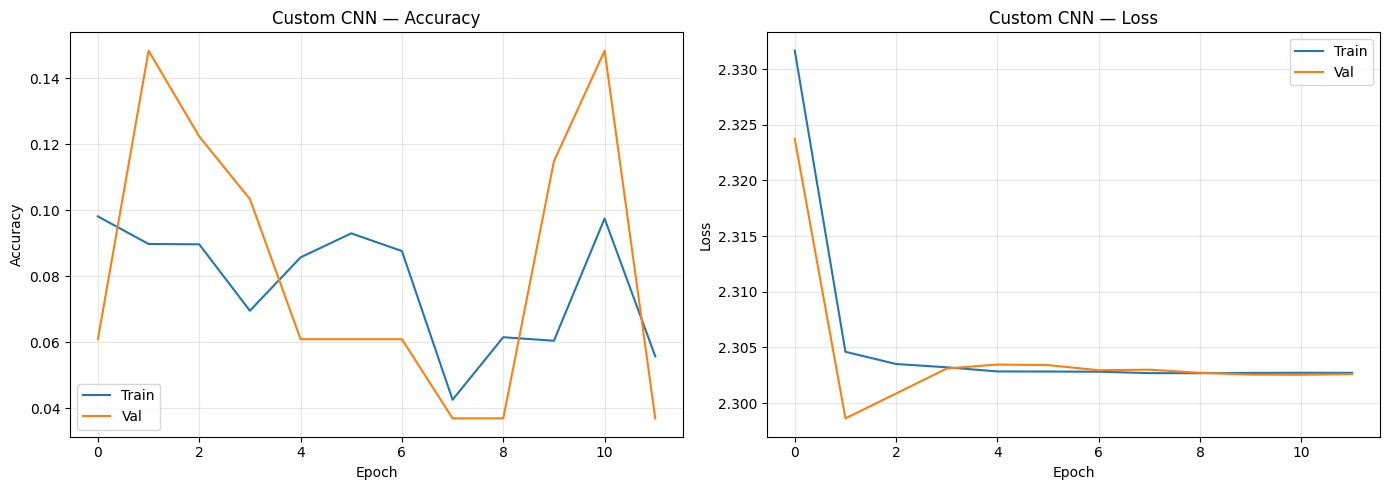

In [7]:
plot_training_curves(
    history.history,
    title="Custom CNN",
    save_path=os.path.join("..", "outputs", "plots", "custom_cnn_curves.png"),
)

## 5. Evaluate on Test Set

In [8]:
results = evaluate_model(model, test_ds, class_names)
print(f"Test Accuracy: {results['accuracy']:.4f}")
print("\nClassification Report:")
print(results["report"])

Test Accuracy: 0.1488

Classification Report:
              precision    recall  f1-score   support

     battery       0.00      0.00      0.00       122
  biological       0.00      0.00      0.00       121
   cardboard       0.00      0.00      0.00       230
     clothes       0.15      1.00      0.26       298
       glass       0.00      0.00      0.00       300
       metal       0.00      0.00      0.00       149
       paper       0.00      0.00      0.00       207
     plastic       0.00      0.00      0.00       257
       shoes       0.00      0.00      0.00       245
       trash       0.00      0.00      0.00        74

    accuracy                           0.15      2003
   macro avg       0.01      0.10      0.03      2003
weighted avg       0.02      0.15      0.04      2003



2026-02-12 16:10:51.197159: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/home/yuujin/school/cv-final-project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/yuujin/school/cv-final-project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/yuujin/school/cv-final-project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precisi

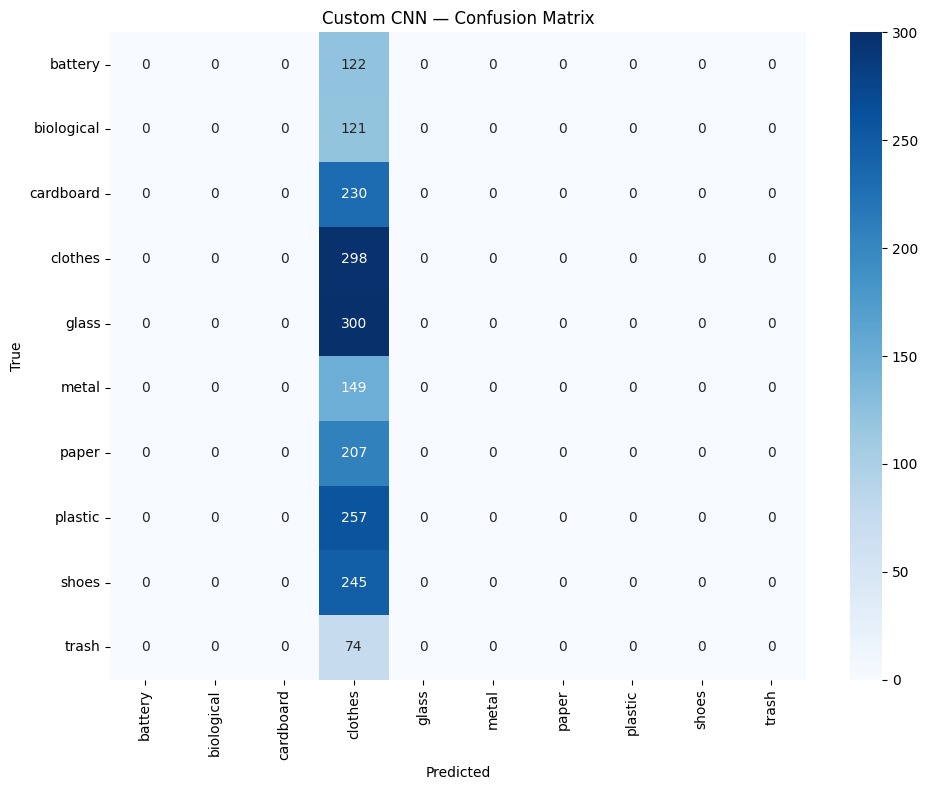

In [9]:
plot_confusion_matrix(
    results["confusion_matrix"],
    class_names,
    title="Custom CNN — Confusion Matrix",
    save_path=os.path.join("..", "outputs", "plots", "custom_cnn_cm.png"),
)